# **<span style="color:cyan">The Next Study?</span>**

## Configuration

In [1]:
import sys
import os
import joblib
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
from sklearn.preprocessing import normalize

# racine du projet
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Racine ajoutée : {project_root}")

Racine ajoutée : c:\Users\aurel\Desktop\Projects\PUSH ON GIT\ResearchPapersRecommandationSystem


In [2]:
from src.data_loading import load_articles, load_profile_keywords
from src.text_vectorizer import load_tfidf_elements
from src.profile_builder import build_profile_text, profile_to_vector
from src.recommender import (
    recommend_for_profile,
    recommend_hot_articles,
    recommend_similar_to_article,
    update_profile_with_likes,
)
from src.embeddings import get_or_compute_article_embeddings, encode_texts
from src.utils import plot_article_space, plot_comparaison
from src.config import ARTICLES_PATH

In [3]:
os.environ["DEBUG_L2_NORMS"] = "1"
plt.style.use('dark_background')
models_dir = project_root + "/models"

In [4]:
# Chargement des data
print(">> Loading data...")
articles_df = load_articles(ARTICLES_PATH)
profile_kw_df = load_profile_keywords()

print(f"  - {len(articles_df)} articles loaded")
articles_df[["id", "title", "field", "year"]].head()

>> Loading data...
  - 58891 articles loaded


,id,title,field,year
0,W2124351063,Search and clustering orders of magnitude fast...,Machine learning,2010
1,W2097360283,Regularization Paths for Generalized Linear Mo...,Machine learning,2010
2,W1533861849,Understanding the difficulty of training deep ...,Machine learning,2010
3,W2342249984,Data Structures for Statistical Computing in P...,Machine learning,2010
4,W2134843796,Multiple imputation using chained equations: I...,Machine learning,2010


## **<span style="color:blue">I. Vectorisation TF-IDF :</span>**

In [5]:
# TF-IDF sur le texte des articles
print(">> Fitting TF-IDF vectorizer...")
# vectorizer, X_tfidf = fit_vectorizer(articles_df["text"])
vectorizer, X_tfidf = load_tfidf_elements()
print(f"  - Matrix shape: {X_tfidf.shape}\n")

# save_tfidf_elements(vectorizer, X_tfidf) # on save les elements

>> Fitting TF-IDF vectorizer...


c:\Users\aurel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


  - Matrix shape: (58891, 500000)



c:\Users\aurel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


On va ici construire une PCA sur la matrice TF-IDF pour poouvoir la representer dans l'espace 2D de ses composantes principales. On ferra ensuite la même avec l'Embedding, pour à la fin comparer les deux approches

In [6]:
# import numpy as np
# import scipy.sparse as sp
# from sklearn.decomposition import TruncatedSVD
# from sklearn.preprocessing import normalize

# RANDOM_STATE = 42
# k = 100  # <-- tu veux 100 composantes

# Xs = X_tfidf

# # 0) securite: CSR + float32
# if not sp.issparse(Xs):
#     raise TypeError("Xs doit etre une matrice scipy.sparse")
# Xs = Xs.tocsr().astype(np.float32)

# # 1) meme preprocessing que tu faisais
# Xs = normalize(Xs, norm="l2", axis=1, copy=False)

# # 2) SVD tronquee (equivalent PCA pour sparse TF-IDF)
# svd = TruncatedSVD(
#     n_components=k,
#     algorithm="randomized",
#     n_iter=7,
#     random_state=RANDOM_STATE
# )

# Z_100 = svd.fit_transform(Xs)   # (58876, 100)

# print("Z_100 shape:", Z_100.shape)
# print("Cum explained variance (100):", float(np.sum(svd.explained_variance_ratio_)))

Z_100 shape: (58891, 100)
Cum explained variance (100): 0.08336315304040909


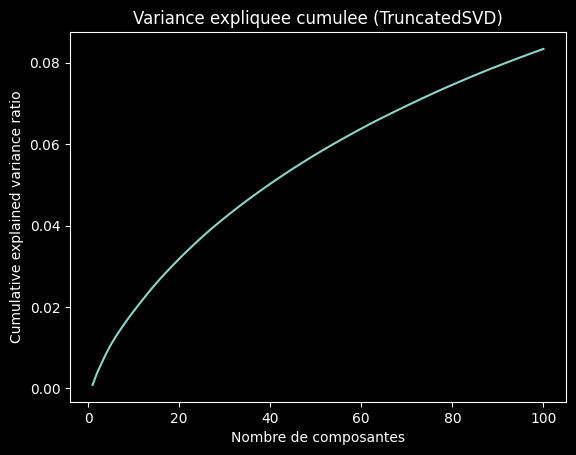

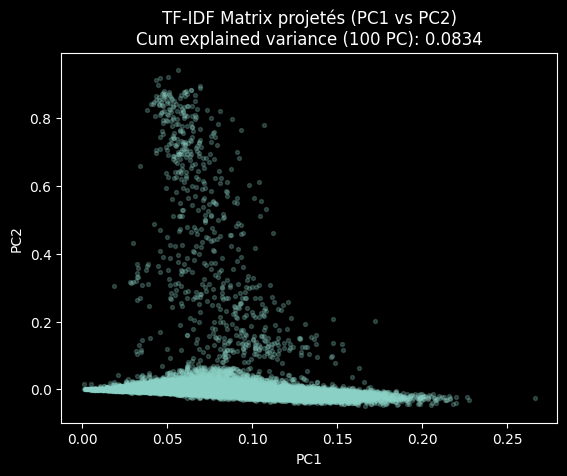

In [14]:
# evr = svd.explained_variance_ratio_
# cum = np.cumsum(evr)

# plt.figure()
# plt.plot(np.arange(1, len(cum)+1), cum)
# plt.title("Variance expliquee cumulee (TruncatedSVD)")
# plt.xlabel("Nombre de composantes")
# plt.ylabel("Cumulative explained variance ratio")
# plt.show()

# # 4) Scatter 2D sur PC1-PC2
# plt.figure()
# plt.scatter(Z_100[:, 0], Z_100[:, 1], s=8, alpha=0.25)
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.title("TF-IDF Matrix projetés (PC1 vs PC2)\nCum explained variance (100 PC): 0.0834")
# plt.show()

In [ ]:
def project_external_vector(x_ext, svd_model):
    # x_ext: (500000,) ou (1,500000), dense ou sparse
    if sp.issparse(x_ext):
        x_row = x_ext.tocsr()
        if x_row.shape[0] != 1:
            x_row = x_row.reshape(1, -1)
    else:
        x_ext = np.asarray(x_ext)
        if x_ext.ndim == 1:
            x_ext = x_ext.reshape(1, -1)
        x_row = sp.csr_matrix(x_ext)

    x_row = x_row.astype(np.float32)
    x_row = normalize(x_row, norm="l2", axis=1, copy=False)

    return svd_model.transform(x_row)  # (1, 100)

In [9]:
# joblib.dump(svd, models_dir + "/svd_model.joblib")
# np.save(models_dir + "/Z_100.npy", Z_100.astype(np.float32))

In [6]:
svd = joblib.load(models_dir + "/svd_model.joblib")
Z_100 = np.load(models_dir + "/Z_100.npy")

c:\Users\aurel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### A/ Recommandation d'articles basées sur le profil utilisateur

In [7]:
# Simuler des préférences utilisateur
prefs = {
    "field": ["machine_learning", "recommender_systems"],
    "type": ["empirical"],
    "impact": ["high_impact"],
}

print(">> Building user profile from prefs:", prefs)
profile_text = build_profile_text(prefs, profile_kw_df)
print("  - Profile text:\n", profile_text[:300], "...\n")
v_profile = profile_to_vector(profile_text, vectorizer)
print(">> Recommending articles for this profile...")
recs_profile_tf = recommend_for_profile(
    v_profile, X_tfidf, articles_df, top_k=5
)
print("Top-5 for profile:")
recs_profile_tf[["id", "title", "field", "year"]]

>> Building user profile from prefs: {'field': ['machine_learning', 'recommender_systems'], 'type': ['empirical'], 'impact': ['high_impact']}
  - Profile text:
 machine learning supervised learning unsupervised learning classification regression clustering data mining recommender systems collaborative filtering content based recommendation ranking user preference personalization empirical study real world data estimation experimental evaluation numerical re ...

>> Recommending articles for this profile...
[norms] v_profile: rows_sampled=1 min=1.000000 max=1.000000 mean=1.000000 zeros=0
Top-5 for profile:


,id,title,field,year
5213,W2024095636,"Survey on Collaborative Filtering, Content-bas...",Recommender system,2015
43,W1570448133,Data Mining: Practical Machine Learning Tools ...,Machine learning,2011
27011,W4394867065,A Review on Analysis of K-Means Clustering Mac...,Linear algebra,2024
5063,W4250893105,Collaborative Filtering Recommender Systems,Recommender system,2011
5246,W2962818688,Collaborative Filtering Bandits,Recommender system,2016


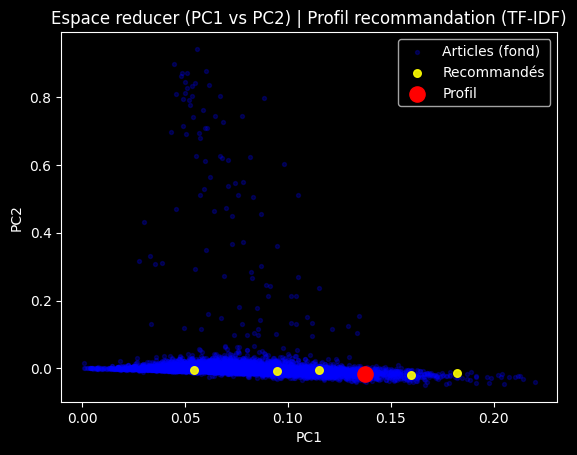

In [8]:
plot_article_space(
    X_tfidf,
    svd,
    recs_profile_tf,
    v_profile=v_profile,
    pc_x=1,
    pc_y=2,
    sample_bg=10000,
    annotate_top=False,
    mode="sparse",
    title="Profil recommandation (TF-IDF)"
 )

### B/ Recommendation d'articles basées sur les articles likés

In [9]:
liked_ids = recs_profile_tf["id"].iloc[:2].tolist()
print("User likes these articles:", liked_ids)
v_profile_updated = update_profile_with_likes(
    v_profile, liked_ids, X_tfidf, articles_df
)
recs_after_likes_tf = recommend_for_profile(
    v_profile_updated,
    X_tfidf,
    articles_df,
    top_k=5,
    exclude_ids=set(liked_ids),  # pour ne pas reproposer les memes
)

print("Top-5 after likes (updated profile):")
recs_after_likes_tf[["id", "title", "field", "year"]]

User likes these articles: ['W2024095636', 'W1570448133']
[norms] v_profile: rows_sampled=1 min=1.000000 max=1.000000 mean=1.000000 zeros=0
Top-5 after likes (updated profile):


,id,title,field,year
5642,W4391305523,Systematic Literature Review on Recommender Sy...,Recommender system,2024
5109,W2113339754,A survey of job recommender systems,Recommender system,2012
5063,W4250893105,Collaborative Filtering Recommender Systems,Recommender system,2011
5018,W1999627569,A Collaborative Filtering Recommendation Algor...,Recommender system,2010
5470,W3130481949,A Review of Content-Based and Context-Based Re...,Recommender system,2021


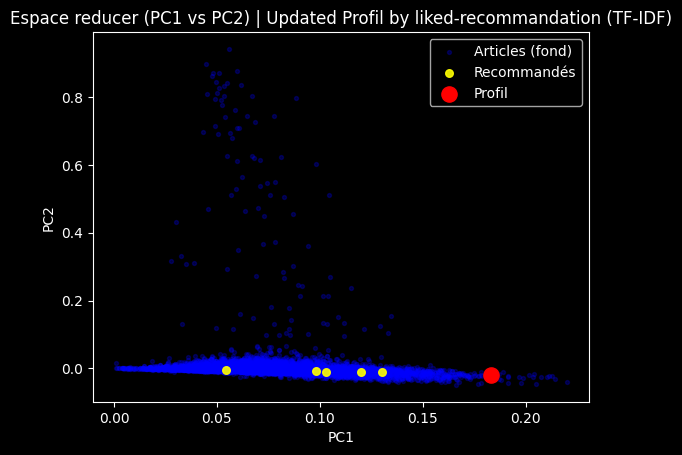

In [10]:
plot_article_space(
    X_tfidf,
    svd,
    recs_after_likes_tf,
    v_profile=v_profile_updated,
    pc_x=1,
    pc_y=2,
    sample_bg=10000,
    annotate_top=False,
    mode="sparse",
    title="Updated Profil by liked-recommandation (TF-IDF)"
 )

### C/ Recommandation d'articles basées sur les articles populaires (arXiv)

In [11]:
# Hot topics (arXiv ou corpus) + hot articles
print(">> Recommending hot articles...")
recs_hot_tfidf = recommend_hot_articles(articles_df, method="tfidf", top_k=5)
print("Top-5 hot articles:")
recs_hot_tfidf[["id", "title", "field", "year", "cite_nb"]]

>> Recommending hot articles...
[INFO] Trends charges depuis le cache
Top-5 hot articles:


,id,title,field,year,cite_nb
31218,W3038568908,Radiation Resistant Camera System for Monitori...,Physics,2020,801215
5685,W7120272634,PROMISE: Process Reward Models Unlock Test-Tim...,Recommender system,2026,0
30409,W7119233913,Global Dynamics and Stabilization of Zero-Mode...,Graph theory,2026,0
7726,W7118586097,Interactive Field: A Descriptive Study of Shar...,Human–computer interaction,2026,0
5687,W7124248251,Ego-Defensive Blocking in AI User Interactions,Recommender system,2026,0


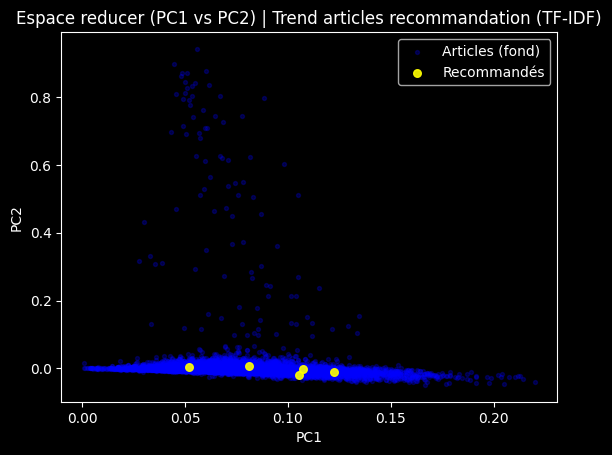

In [12]:
plot_article_space(
    X_tfidf,
    svd,
    recs_hot_tfidf,
    v_profile=None,
    pc_x=1,
    pc_y=2,
    sample_bg=10000,
    annotate_top=False,
    mode="sparse",
    title="Trend articles recommandation (TF-IDF)"
 )

### D/ Recommendation basé sur un article

In [13]:
first_id = recs_profile_tf.iloc[0]["id"]
print(f">> Recommending articles similar to {first_id} ...")
recs_sim_tf = recommend_similar_to_article(
    first_id, X_tfidf, articles_df, top_k=5
)
print("Similar articles:")
recs_sim_tf[["id", "title", "field", "year"]]

>> Recommending articles similar to W2024095636 ...
[norms] X_sample: rows_sampled=25 min=1.000000 max=1.000000 mean=1.000000 zeros=0
[norms] query_vec_from_catalog: rows_sampled=1 min=1.000000 max=1.000000 mean=1.000000 zeros=0
Similar articles:


,id,title,field,year
5642,W4391305523,Systematic Literature Review on Recommender Sy...,Recommender system,2024
5109,W2113339754,A survey of job recommender systems,Recommender system,2012
5063,W4250893105,Collaborative Filtering Recommender Systems,Recommender system,2011
4992,W1412447802,Recommender Systems,Recommender system,2010
4990,W1597703625,Recommender Systems: An Introduction,Recommender system,2010


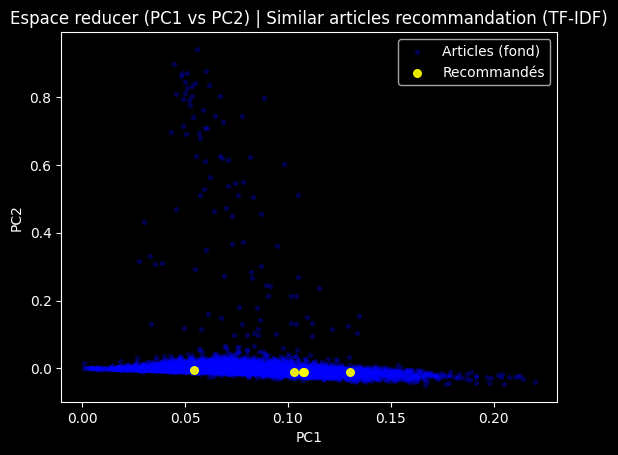

In [14]:
plot_article_space(
    X_tfidf,
    svd,
    recs_sim_tf,
    v_profile=None,
    pc_x=1,
    pc_y=2,
    sample_bg=10000,
    annotate_top=False,
    mode="sparse",
    title="Similar articles recommandation (TF-IDF)"
 )

## **<span style="color:blue">II. Embeddings (LLM) :</span>**

In [15]:
print(">> Computing article embeddings...")
X_emb, model = get_or_compute_article_embeddings(articles_df)
print(f"  - Embedding matrix shape: {X_emb.shape}\n")

>> Computing article embeddings...
Loading cached embeddings...
  - Embedding matrix shape: (58891, 384)



In [25]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA

# RANDOM_STATE = 42

# X = X_emb.astype(np.float32)  # (58891, 384)

# # 1) Standardisation (centrer / reduire) -> classique pour PCA
# scaler = StandardScaler(with_mean=True, with_std=True)
# X_std = scaler.fit_transform(X)

# # 2) PCA (tu choisis k)
# k = 100
# pca = PCA(n_components=k, random_state=RANDOM_STATE)
# Z = pca.fit_transform(X_std)   # (58891, k)

# print("Z shape:", Z.shape)
# print("Cum explained variance (k):", float(np.sum(pca.explained_variance_ratio_)))

# # 3) Plot variance expliquée (bar + cumulée)
# evr = pca.explained_variance_ratio_
# cum = np.cumsum(evr)

Z shape: (58891, 100)
Cum explained variance (k): 0.7179665565490723


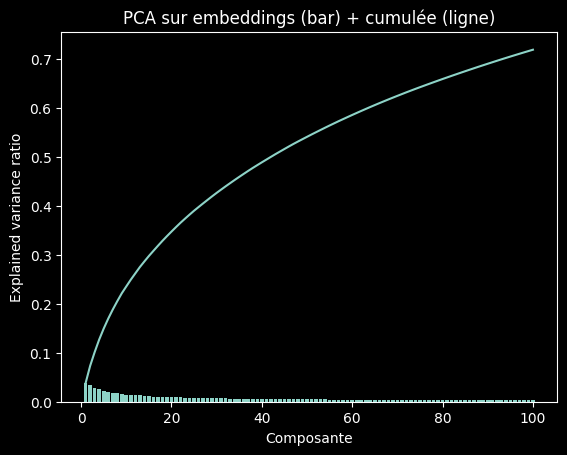

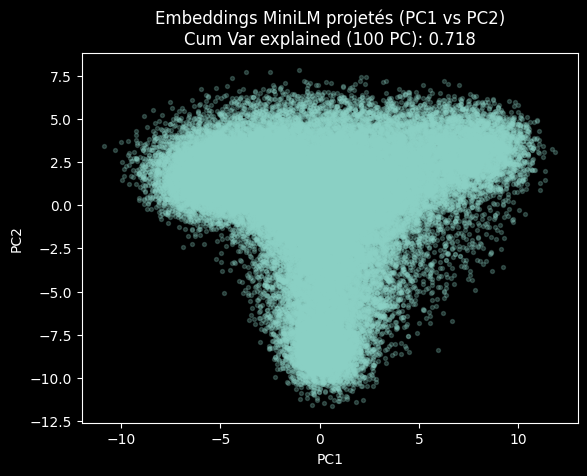

In [26]:
# plt.figure()
# plt.bar(np.arange(1, k+1), evr)
# plt.plot(np.arange(1, k+1), cum)
# plt.xlabel("Composante")
# plt.ylabel("Explained variance ratio")
# plt.title("PCA sur embeddings (bar) + cumulée (ligne)")
# plt.show()

# # 4) Scatter 2D sur PC1-PC2
# plt.figure()
# plt.scatter(Z[:, 0], Z[:, 1], s=8, alpha=0.25)
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.title("Embeddings MiniLM projetés (PC1 vs PC2)\nCum Var explained (100 PC): 0.718")
# plt.show()

In [28]:
# joblib.dump({"scaler": scaler, "pca": pca}, models_dir + "/pca_minilm.joblib")
# np.save(models_dir + "/Z_minilm.npy", Z.astype(np.float32))

In [16]:
obj = joblib.load(models_dir + "/pca_minilm.joblib")
scaler = obj["scaler"]
pca = obj["pca"]

Z_minilm = np.load(models_dir + "/Z_minilm.npy")  # optionnel
print("PCA loaded, Z_minilm:", Z_minilm.shape)

PCA loaded, Z_minilm: (58891, 100)


c:\Users\aurel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\aurel\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### A/ Recommandation d'articles basées sur le profil utilisateur

In [17]:
prefs = {
    "field": ["machine_learning", "recommender_systems"],
    "type": ["empirical"],
    "impact": ["high_impact"],
}
print(">> Building user profile from prefs:", prefs)
profile_text = build_profile_text(prefs, profile_kw_df)
print("  - Profile text:\n", profile_text[:200], "...\n")

if X_emb is not None and model is not None:
    profile_embedding = encode_texts([profile_text], model, normalize=True)
    
print("  - Profile embedding:", profile_embedding.shape)

# Recommandations basées sur le profil
print(">> Recommending articles for this profile...")
recs_profile = recommend_for_profile(
    profile_embedding, X_emb, articles_df, top_k=5
)
print("Top-5 for profile:")
recs_profile[["id", "title", "field", "year"]]

>> Building user profile from prefs: {'field': ['machine_learning', 'recommender_systems'], 'type': ['empirical'], 'impact': ['high_impact']}
  - Profile text:
 machine learning supervised learning unsupervised learning classification regression clustering data mining recommender systems collaborative filtering content based recommendation ranking user prefer ...

  - Profile embedding: (1, 384)
>> Recommending articles for this profile...
[norms] v_profile: rows_sampled=1 min=1.000000 max=1.000000 mean=1.000000 zeros=0
Top-5 for profile:


,id,title,field,year
5626,W4396903457,Intelligent classification and personalized re...,Recommender system,2024
5106,W2019313057,Impact of data characteristics on recommender ...,Recommender system,2012
5018,W1999627569,A Collaborative Filtering Recommendation Algor...,Recommender system,2010
5113,W2950332743,Empirical Analysis of Predictive Algorithms fo...,Recommender system,2013
5541,W4313316862,E-Learning Course Recommender System Using Col...,Recommender system,2022


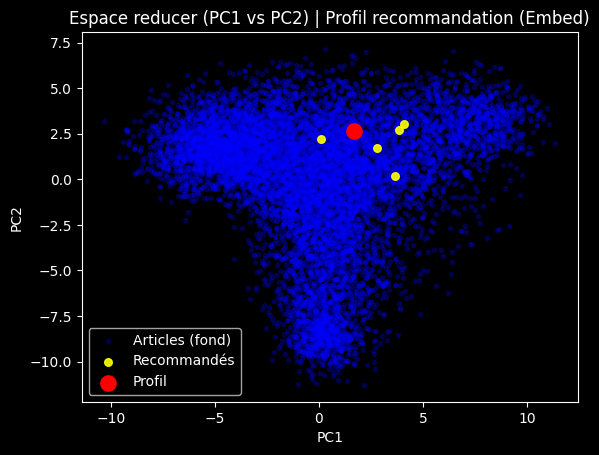

In [18]:
plot_article_space(
    X_emb,
    pca,
    recs_profile,
    v_profile=profile_embedding,
    pc_x=1,
    pc_y=2,
    sample_bg=10000,
    annotate_top=False,
    mode="dense",
    preproc=scaler,
    title="Profil recommandation (Embed)"
 )

### B/ Recommendation d'articles basées sur les articles likés

In [19]:
liked_ids = recs_profile["id"].iloc[:2].tolist()
print("User likes these articles:", liked_ids)
profile_emb_updated = update_profile_with_likes(
    profile_embedding, liked_ids, X_emb, articles_df, desparse=True
)
print("Updated profile vector:\n", profile_emb_updated.shape)

recs_after_likes = recommend_for_profile(
    profile_emb_updated,
    X_emb,
    articles_df,
    top_k=5,
    exclude_ids=set(liked_ids),  # pour ne pas reproposer les memes
)

print("Top-5 after likes (updated profile):")
recs_after_likes[["id", "title", "field", "year"]]

User likes these articles: ['W4396903457', 'W2019313057']
[norms] v_profile_before_feedback: rows_sampled=1 min=1.000000 max=1.000000 mean=1.000000 zeros=0
[norms] v_profile_after_feedback: rows_sampled=1 min=1.000000 max=1.000000 mean=1.000000 zeros=0
Updated profile vector:
 (1, 384)
[norms] v_profile: rows_sampled=1 min=1.000000 max=1.000000 mean=1.000000 zeros=0
Top-5 after likes (updated profile):


,id,title,field,year
5113,W2950332743,Empirical Analysis of Predictive Algorithms fo...,Recommender system,2013
5018,W1999627569,A Collaborative Filtering Recommendation Algor...,Recommender system,2010
5116,W2003274231,A new user similarity model to improve the acc...,Recommender system,2013
5424,W3097103183,"Recommendation Systems: Algorithms, Challenges...",Recommender system,2020
5028,W2105953200,Collaborative Filtering Recommender Systems,Recommender system,2011


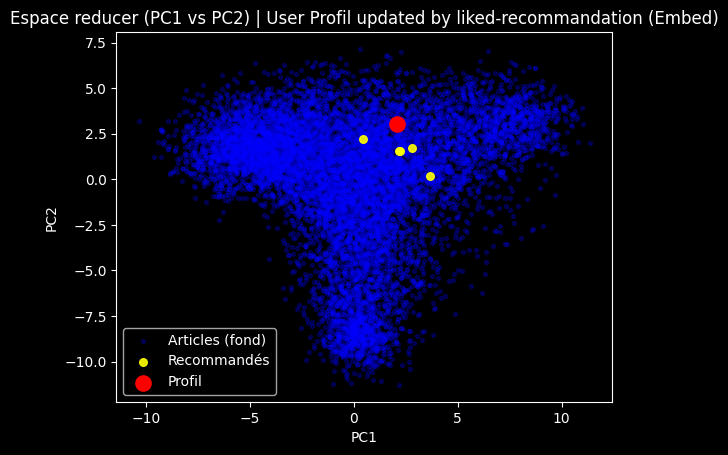

In [22]:
plot_article_space(
    X_emb,
    pca,
    recs_after_likes,
    v_profile=profile_emb_updated,
    pc_x=1,
    pc_y=2,
    sample_bg=10000,
    annotate_top=False,
    mode="dense",
    preproc=scaler,
    title="User Profil updated by liked-recommandation (Embed)",
 )

### C/ Recommandation d'articles basées sur les articles populaires (arXiv)

In [23]:
print(">> Recommending hot articles...")
recs_hot = recommend_hot_articles(articles_df, method="semantic", model=model, top_k=5)
print("Top-5 hot articles:")
recs_hot[["id", "title", "field", "year", "cite_nb"]]

>> Recommending hot articles...
[INFO] Trends charges depuis le cache
Loading cached embeddings...
Top-5 hot articles:


,id,title,field,year,cite_nb
5685,W7120272634,PROMISE: Process Reward Models Unlock Test-Tim...,Recommender system,2026,0
11434,W7119135457,When Do Tools and Planning Help LLMs Think? A ...,Software engineering,2026,0
4262,W7120079053,Predictable Gradient Manifolds in Deep Learnin...,Reinforcement learning,2026,0
10996,W7119735776,GlimpRouter: Efficient Collaborative Inference...,Distributed computing,2026,0
4257,W7120085034,Reinforced Efficient Reasoning via Semanticall...,Reinforcement learning,2026,0


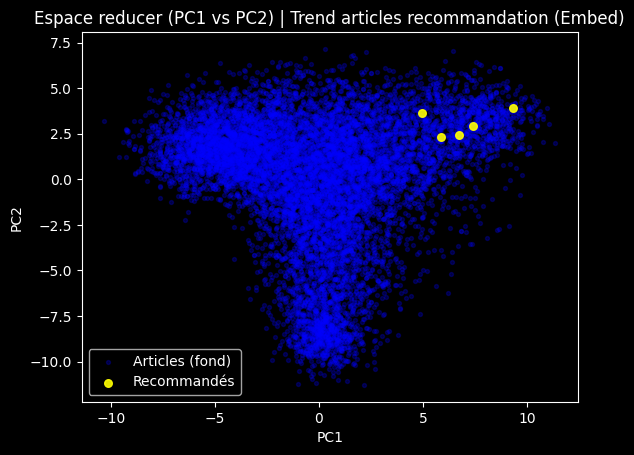

In [24]:
plot_article_space(
    X_emb,
    pca,
    recs_hot,
    v_profile=None,
    pc_x=1,
    pc_y=2,
    sample_bg=10000,
    annotate_top=False,
    mode="dense",
    preproc=scaler,
    title="Trend articles recommandation (Embed)"
 )

### D/ Recommendation basé sur un article

In [25]:
first_id = recs_profile.iloc[0]["id"]
print(f">> Recommending articles similar to {first_id} ...")
recs_sim = recommend_similar_to_article(
    first_id, X_emb, articles_df, top_k=5
)
print("Similar articles:")
recs_sim[["id", "title", "field", "year"]]

>> Recommending articles similar to W4396903457 ...
[norms] X_sample: rows_sampled=25 min=1.000000 max=1.000000 mean=1.000000 zeros=0
[norms] query_vec_from_catalog: rows_sampled=1 min=1.000000 max=1.000000 mean=1.000000 zeros=0
Similar articles:


,id,title,field,year
5056,W2148398661,Recommender Systems: An Overview,Recommender system,2011
5422,W3097904695,Artificial intelligence in recommender systems,Recommender system,2020
5028,W2105953200,Collaborative Filtering Recommender Systems,Recommender system,2011
5353,W2811035854,A trust-based collaborative filtering algorith...,Recommender system,2018
5513,W4225321042,A systematic review and research perspective o...,Recommender system,2022


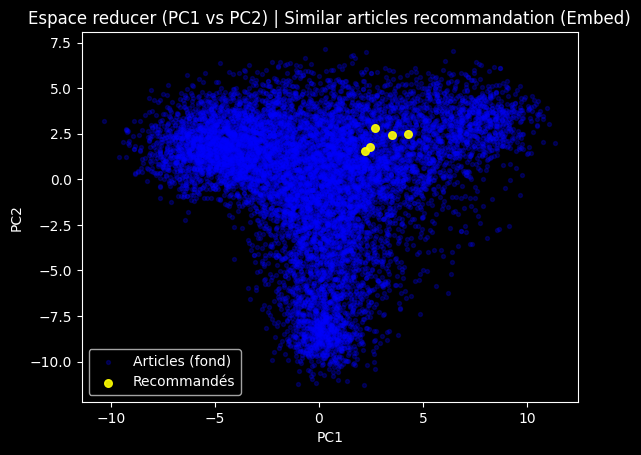

In [26]:
plot_article_space(
    X_emb,
    pca,
    recs_sim,
    v_profile=None,
    pc_x=1,
    pc_y=2,
    sample_bg=10000,
    annotate_top=False,
    mode="dense",
    preproc=scaler,
    title="Similar articles recommandation (Embed)"
 )

## **<span style="color:blue">III. Comparaison TF-IDF vs Embeddings</span>**

**Recommandation d'articles basées sur le profil utilisateur**

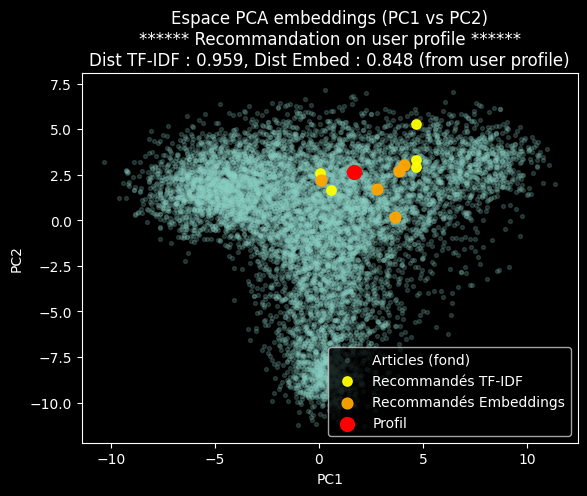

In [27]:
plot_comparaison(
    articles_df=articles_df,
    X_emb=X_emb,                 # embeddings MiniLM (n,384)
    scaler=scaler,
    pca=pca,
    recs_tfidf_df=recs_profile_tf,     # tes recos TF-IDF (avec colonne 'id')
    recs_emb_df=recs_profile,          # tes recos embeddings (avec colonne 'id')
    profile_emb=profile_embedding,             # ou un (384,)
    pc_x=1, pc_y=2,
    title="\n****** Recommandation on user profile ******",
    sample_bg=10000,
    annotate_top=None
)

**Recommandation d'articles basées sur les articles likés**

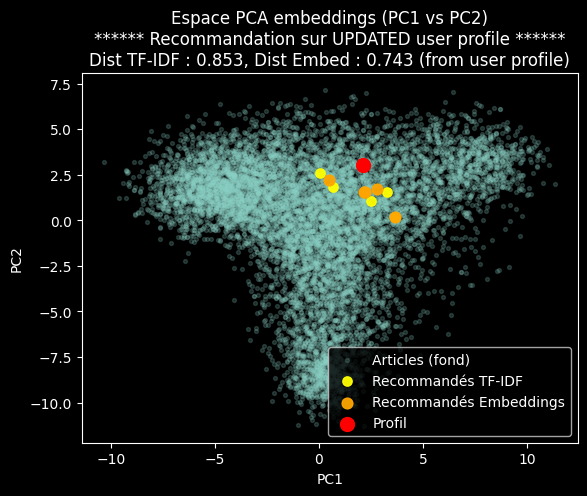

In [28]:
plot_comparaison(
    articles_df=articles_df,
    X_emb=X_emb,                 # embeddings MiniLM (n,384)
    scaler=scaler,
    pca=pca,
    recs_tfidf_df=recs_after_likes_tf,     # tes recos TF-IDF (avec colonne 'id')
    recs_emb_df=recs_after_likes,          # tes recos embeddings (avec colonne 'id')
    profile_emb=profile_emb_updated,             # ou un (384,)
    pc_x=1, pc_y=2,
    title="\n****** Recommandation sur UPDATED user profile ******",
    sample_bg=10000,
    annotate_top=None
)

**Recommandation d'articles basées sur les articles populaires (arXiv)**

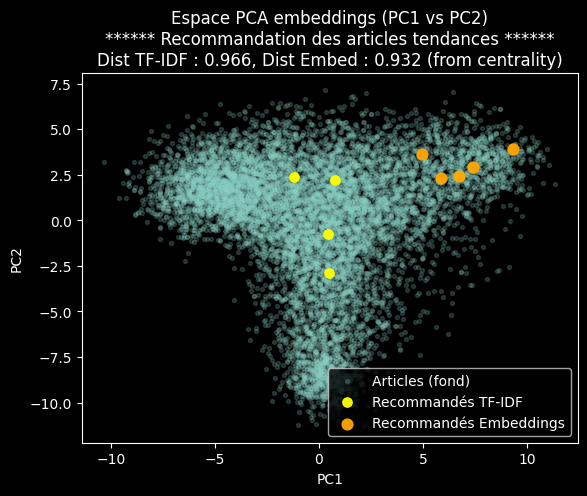

In [29]:
plot_comparaison(
    articles_df=articles_df,
    X_emb=X_emb,                 # embeddings MiniLM (n,384)
    scaler=scaler,
    pca=pca,
    recs_tfidf_df=recs_hot_tfidf,     # tes recos TF-IDF (avec colonne 'id')
    recs_emb_df=recs_hot,          # tes recos embeddings (avec colonne 'id')
    profile_emb=None,             # ou un (384,)
    pc_x=1, pc_y=2,
    title="\n****** Recommandation des articles tendances ******",
    sample_bg=10000,
    annotate_top=None
)

**Recommendation basé sur un article**

In [30]:
# get a random id from articles_df
random_id = articles_df.sample(n=1, random_state=42).iloc[0]["id"]
print(f">> Recommending articles similar to {random_id} ...")
# method 1: TF-IDF
recs_sim_tft = recommend_similar_to_article(
    random_id, X_tfidf, articles_df, top_k=5
)
print("Similar articles (TF-IDF):")
display(recs_sim_tft[["id", "title", "field", "year"]])

# method 2: Embeddings
recs_sim_emb = recommend_similar_to_article(
    random_id, X_emb, articles_df, top_k=5
)
print("Similar articles (Embeddings):")
display(recs_sim_emb[["id", "title", "field", "year"]])

>> Recommending articles similar to W1776473873 ...
[norms] X_sample: rows_sampled=25 min=1.000000 max=1.000000 mean=1.000000 zeros=0
[norms] query_vec_from_catalog: rows_sampled=1 min=1.000000 max=1.000000 mean=1.000000 zeros=0
Similar articles (TF-IDF):


,id,title,field,year
31807,W2201035149,PDF4LHC recommendations for LHC Run II,Particle physics,2016
32069,W4221165118,The PDF4LHC21 combination of global PDF fits f...,Particle physics,2022
32007,W2996124648,New CTEQ global analysis of quantum chromodyna...,Particle physics,2021
31806,W2294966860,New parton distribution functions from a globa...,Particle physics,2016
31720,W2951057061,Handbook of LHC Higgs Cross Sections: 3. Higgs...,Particle physics,2013


[norms] X_sample: rows_sampled=25 min=1.000000 max=1.000000 mean=1.000000 zeros=0
[norms] query_vec_from_catalog: rows_sampled=1 min=1.000000 max=1.000000 mean=1.000000 zeros=0
Similar articles (Embeddings):


,id,title,field,year
31807,W2201035149,PDF4LHC recommendations for LHC Run II,Particle physics,2016
11143,W1965888463,LHAPDF6: parton density access in the LHC prec...,Software engineering,2015
32069,W4221165118,The PDF4LHC21 combination of global PDF fits f...,Particle physics,2022
32010,W3112126290,"Parton distributions from LHC, HERA, Tevatron ...",Particle physics,2021
32075,W3101204406,Precision phenomenology with MCFM,Particle physics,2022


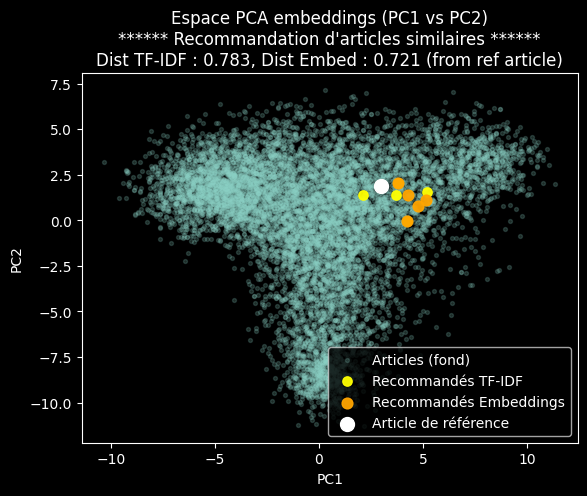

In [33]:
# get the random article random_id embed vector
random_art_id = articles_df[articles_df["id"] == random_id].index.to_numpy()[0]
random_art_emb = X_emb[random_art_id]

plot_comparaison(
    articles_df=articles_df,
    X_emb=X_emb,                 # embeddings MiniLM (n,384)
    scaler=scaler,
    pca=pca,
    recs_tfidf_df=recs_sim_tft,     # tes recos TF-IDF (avec colonne 'id')
    recs_emb_df=recs_sim_emb,          # tes recos embeddings (avec colonne 'id')
    profile_emb=random_art_emb,             # ou un (384,)
    est_prof=False,
    pc_x=1, pc_y=2,
    title="\n****** Recommandation d'articles similaires ******",
    sample_bg=10000,
    annotate_top=None
)